# ResNet — Deep Residual Learning for Image Recognition

This notebook builds a **small ResNet from scratch in PyTorch**, trains it on **CIFAR-10**, and compares it against a **plain (non-residual) CNN of the same depth** to show why skip connections matter.


In [1]:
# Install / import libraries (Kaggle already has torch, but keep explicit for Colab)
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import time, os, json, math

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

PyTorch version: 2.10.0+cu128
CUDA available: True


device(type='cuda')

## 1. Load CIFAR-10

Standard normalization. We keep the setup simple so the comparison focuses on the architecture.

In [2]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

batch_size = 128

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

classes = ('plane','car','bird','cat','deer','dog','frog','horse','ship','truck')
print(f"Train batches: {len(trainloader)}, Test batches: {len(testloader)}")

  0%|          | 0.00/170M [00:00<?, ?B/s]

  0%|          | 32.8k/170M [00:00<16:21, 174kB/s]

  0%|          | 65.5k/170M [00:00<16:29, 172kB/s]

  0%|          | 98.3k/170M [00:00<16:34, 171kB/s]

  0%|          | 131k/170M [00:00<16:32, 172kB/s] 

...

100%|█████████▉| 170M/170M [20:07<00:00, 136kB/s]

100%|█████████▉| 170M/170M [20:07<00:00, 137kB/s]

100%|█████████▉| 170M/170M [20:07<00:00, 130kB/s]

100%|██████████| 170M/170M [20:07<00:00, 141kB/s]

Train batches: 391, Test batches: 79


## 2. Plain block and PlainNet baseline

A plain deep block is just two conv layers with BN and ReLU. We stack it to match the depth of the ResNet we will build.

In [3]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = F.relu(self.bn2(self.conv2(out)))
        return out

class PlainNet(nn.Module):
    def __init__(self, block_counts=(2,2,2,2), num_classes=10):
        super().__init__()
        self.in_ch = 64
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.stage1 = self._make_stage(64, 64, block_counts[0], stride=1)
        self.stage2 = self._make_stage(64, 128, block_counts[1], stride=2)
        self.stage3 = self._make_stage(128, 256, block_counts[2], stride=2)
        self.stage4 = self._make_stage(256, 512, block_counts[3], stride=2)
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(512, num_classes)
        self._init_weights()

    def _make_stage(self, in_ch, out_ch, num_blocks, stride):
        layers = [ConvBlock(in_ch, out_ch, stride=stride)]
        for _ in range(1, num_blocks):
            layers.append(ConvBlock(out_ch, out_ch, stride=1))
        return nn.Sequential(*layers)

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x


## 3. Residual block from scratch

This is the heart of the paper. The block learns a residual mapping and adds the input back.

In [4]:
class ResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)

        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Conv2d(in_ch, out_ch, kernel_size=1, stride=stride, bias=False)
        else:
            self.shortcut = None

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.shortcut is not None:
            x = self.shortcut(x)
        out = out + x
        out = F.relu(out)
        return out


## 4. Small ResNet

Same skeleton as PlainNet, but replacing `ConvBlock` with `ResidualBlock`.

In [5]:
class ResNet(nn.Module):
    def __init__(self, block_counts=(2,2,2,2), num_classes=10):
        super().__init__()
        self.in_ch = 64
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.stage1 = self._make_stage(64, 64, block_counts[0], stride=1)
        self.stage2 = self._make_stage(64, 128, block_counts[1], stride=2)
        self.stage3 = self._make_stage(128, 256, block_counts[2], stride=2)
        self.stage4 = self._make_stage(256, 512, block_counts[3], stride=2)
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(512, num_classes)
        self._init_weights()

    def _make_stage(self, in_ch, out_ch, num_blocks, stride):
        layers = [ResidualBlock(in_ch, out_ch, stride=stride)]
        for _ in range(1, num_blocks):
            layers.append(ResidualBlock(out_ch, out_ch, stride=1))
        return nn.Sequential(*layers)

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x


## 5. Helper functions for training and evaluation

In [6]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        total_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
    return total_loss / total, correct / total


## 6. Train PlainNet and ResNet

We train both networks with the same optimizer settings and plot the curves.

In [7]:
epochs = 25
lr = 0.1
momentum = 0.9
weight_decay = 5e-4

models = {}
histories = {}

for name, ModelClass in [('PlainNet', PlainNet), ('ResNet', ResNet)]:
    print(f"\n=== Training {name} ===")
    model = ModelClass(block_counts=(2,2,2,2), num_classes=10).to(device)
    print(f"Parameters: {count_parameters(model):,}")
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.2)

    train_losses, train_accs = [], []
    test_losses, test_accs = [], []
    start = time.time()
    for ep in range(1, epochs + 1):
        tr_loss, tr_acc = train_epoch(model, trainloader, criterion, optimizer, device)
        te_loss, te_acc = evaluate(model, testloader, criterion, device)
        scheduler.step()
        train_losses.append(tr_loss); train_accs.append(tr_acc)
        test_losses.append(te_loss); test_accs.append(te_acc)
        if ep % 5 == 0 or ep == 1:
            print(f"Epoch {ep:02d} | train loss {tr_loss:.3f} acc {tr_acc:.3f} | test loss {te_loss:.3f} acc {te_acc:.3f}")
    print(f"{name} finished in {time.time()-start:.1f}s")
    models[name] = model
    histories[name] = {
        'train_loss': train_losses, 'train_acc': train_accs,
        'test_loss': test_losses, 'test_acc': test_accs
    }


=== Training PlainNet ===


Parameters: 11,000,138


Epoch 01 | train loss 1.719 acc 0.358 | test loss 1.666 acc 0.401


Epoch 05 | train loss 0.689 acc 0.765 | test loss 0.720 acc 0.754


Epoch 10 | train loss 0.532 acc 0.821 | test loss 1.124 acc 0.680


...

Epoch 05 | train loss 1.175 acc 0.578 | test loss 1.236 acc 0.587


Epoch 10 | train loss 0.576 acc 0.803 | test loss 0.719 acc 0.761


Epoch 15 | train loss 0.276 acc 0.905 | test loss 0.379 acc 0.869


Epoch 20 | train loss 0.227 acc 0.920 | test loss 0.372 acc 0.886


Epoch 25 | train loss 0.091 acc 0.970 | test loss 0.280 acc 0.911
ResNet finished in 1086.7s


## 7. Plot training curves

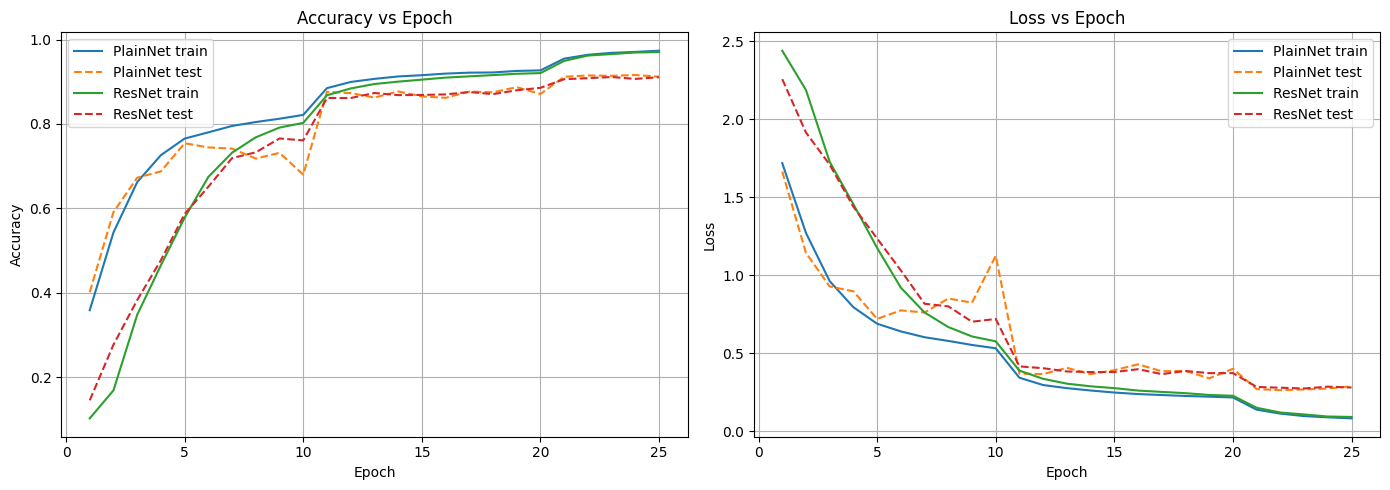


Final test accuracies:
  PlainNet: 91.18%
  ResNet: 91.08%


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, h in histories.items():
    axes[0].plot(range(1, epochs+1), h['train_acc'], label=f'{name} train')
    axes[0].plot(range(1, epochs+1), h['test_acc'], label=f'{name} test', linestyle='--')
axes[0].set_title('Accuracy vs Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

for name, h in histories.items():
    axes[1].plot(range(1, epochs+1), h['train_loss'], label=f'{name} train')
    axes[1].plot(range(1, epochs+1), h['test_loss'], label=f'{name} test', linestyle='--')
axes[1].set_title('Loss vs Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('plain_vs_resnet.png')
plt.show()

print("\nFinal test accuracies:")
for name, h in histories.items():
    print(f"  {name}: {h['test_acc'][-1]*100:.2f}%")

## 8. What the plot tells us

- If the ResNet test curve sits clearly above the plain net curve, the notebook demonstrates the paper’s central claim: skip connections make deeper networks train better.
- If the plain net lags, it is experiencing the **degradation** problem even on CIFAR-10: adding depth without residuals hurts optimization.

## 9. Next steps

- Try bottleneck blocks (`1×1` → `3×3` → `1×1`).
- Increase depth or add data augmentation.
- Swap the step scheduler for a cosine annealing schedule.
- Move to a subset of ImageNet or use transfer learning from torchvision's pretrained ResNet.


In [ ]:
# --- Auto-injected by kaggle_validator: save executed notebook with outputs ---
import shutil, os
if os.path.exists('/kaggle/working/__notebook__.ipynb'):
    shutil.copy('/kaggle/working/__notebook__.ipynb', '/kaggle/working/executed_solution.ipynb')
    print('Executed notebook saved to output folder.')
else:
    import glob
    print(f'Available notebooks in output: {glob.glob("/kaggle/working/*.ipynb")}')